In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df_train_x = pd.read_csv("/content/drive/MyDrive/task-1-brain-age-prediction/X_train.csv")
df_train_x = df_train_x.iloc[:, 1:]
train_x = df_train_x.to_numpy()

df_train_y = pd.read_csv("/content/drive/MyDrive/task-1-brain-age-prediction/y_train.csv")
df_train_y = df_train_y.iloc[:, 1:]
train_y = df_train_y.to_numpy()

df_test_x = pd.read_csv("/content/drive/MyDrive/task-1-brain-age-prediction/X_test.csv")
df_test_x = df_test_x.iloc[:, 1:]
test_x = df_test_x.to_numpy()

print("X_train shape:", train_x.shape)
print("y_train shape:", train_y.shape)
print("X_test shape:", test_x.shape)

X_train shape: (1212, 832)
y_train shape: (1212, 1)
X_test shape: (776, 832)


In [ ]:
combined = np.c_[train_x, train_y]
np.random.shuffle(combined)
train_x = combined[:, :-1]
train_y = combined[:, -1]
train_y = train_y.reshape(-1, 1)
print("X_train shape:", train_x.shape)
print("y_train shape:", train_y.shape)

X_train shape: (1212, 832)
y_train shape: (1212, 1)


In [ ]:
#Outlier detection
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
#1. Impute the data
imputer = SimpleImputer(strategy="median")
train_x_imputed = imputer.fit_transform(train_x)
#2. Standardize the data
scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x_imputed)
#3. PCA
pca = PCA(n_components=2)
train_x_pca = pca.fit_transform(train_x_scaled)
#4. Isolation Forest for outlier detection
iso_forest = IsolationForest(contamination=0.045, random_state=0)  #contamination = 0.045 chosen based on testing the following graph
iso_forest.fit(train_x_pca)
outlier_labels = iso_forest.predict(train_x_pca)  # 1 for inliers, -1 for outliers

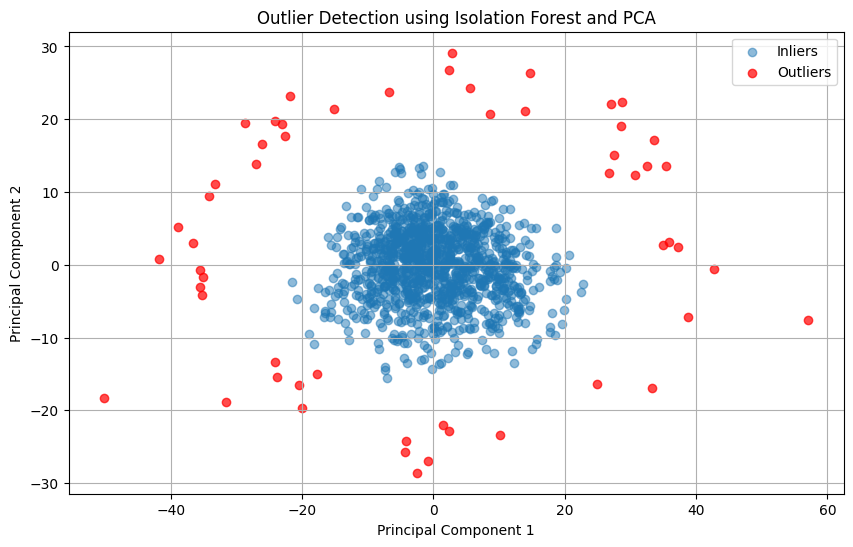

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(train_x_pca[outlier_labels == 1, 0], train_x_pca[outlier_labels == 1, 1], label='Inliers', alpha=0.5)
plt.scatter(train_x_pca[outlier_labels == -1, 0], train_x_pca[outlier_labels == -1, 1], label='Outliers', color='red', alpha=0.7)
plt.title('Outlier Detection using Isolation Forest and PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#keep only the inliers
train_x = train_x[outlier_labels > 0]
train_y = train_y[outlier_labels > 0]
print("X_train shape:", train_x.shape)
print("y_train shape:", train_y.shape)

X_train shape: (1157, 832)
y_train shape: (1157, 1)


In [ ]:
#Preprocess the data based on only the inliers

#Having imputation and standardization separately in both the outlier detection part and this part because the computation
#in outlier detection part included the outliers, here we redo the computation with only inliers.

#Impute the data
imputer = SimpleImputer(strategy="median")
train_x = imputer.fit_transform(train_x)
test_x = imputer.transform(test_x)
#Standardize the data
scaler = StandardScaler()
train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)

In [ ]:
!pip install feature_engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.1/364.1 kB 4.8 MB/s eta 0:00:00


In [ ]:
#Feature Selection

from feature_engine.selection import DropCorrelatedFeatures
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression, SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
#Parameter to tune:
#varianceThreshold's threshold
#DropCorrelatedFeatures' threshold
#SelectKBest's score_func and k

#1, VarianceThreshold to remove low-variance features
variance_threshold = VarianceThreshold(threshold=0.1)

#2. DropCorrelateFeatures to drop highly correlated features
drop_corr_features = DropCorrelatedFeatures(method='pearson', threshold=0.95)

#3. SelectKBest to select the top k features based on f_regression / mutual_info_regression
#f_regression for linear relationship between features target, mutual_info_regression for both linear/nonlinear
#through testing, f_regression gives better performance than mutual_info_regression
select_k_best = SelectKBest(score_func=f_regression, k=200)

#4: SelectFromModel with Lasso uses a simple linear regression to filter out unnacesary features before complex regression
select_from_model = SelectFromModel(Lasso(alpha=0.1))

model = Pipeline([
    ('variance_threshold', variance_threshold),
    #('drop_correlated', drop_corr_features), #without drop_correlated gives better performance
    ('select_k_best', select_k_best),
    ('select_from_model', select_from_model)
])

train_x = model.fit_transform(train_x, train_y)
test_x = model.transform(test_x)

print("X_train shape:", train_x.shape)
print("y_train shape:", test_x.shape)

X_train shape: (1157, 83)
y_train shape: (776, 83)


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
!pip install lightgbm

In [ ]:
!pip install "dask[dataframe]"

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.6/242.6 kB 3.6 MB/s eta 0:00:00


In [ ]:
#Regression
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor

def search_best_parameters(estimator, parameters, train_x, train_y):
    search = GridSearchCV(estimator=estimator, param_grid=parameters, scoring='r2', n_jobs=-1, cv=5, verbose=1)
    search.fit(train_x, train_y)

    print(f"Best params for {estimator.__class__.__name__}: {search.best_params_}")
    print(f"Best score: {search.best_score_}")
    return search.best_estimator_

svr_parameters = {'kernel': ['rbf'], 'C': np.linspace(50, 80, 10), 'epsilon': np.logspace(-8, -1, 8)}

#lgb_parameters = {'boosting_type' : ['gbdt'], 'n_estimators' : [2000], 'learning_rate' : np.logspace(-3, -1, 3), 'num_leaves' : np.logspace(3, 5, 3, base=2).astype(int)}
#best parameters chosen from the above parameter combinations
lgb_parameters = {'boosting_type' : ['gbdt'], 'n_estimators' : [2000], 'learning_rate' : [0.01], 'num_leaves' : [8]}

#lower score than lgb, thus ignored
#gbr_parameters = {'n_estimators' : [2000], 'learning_rate' : [0.01], 'min_samples_split' : [3, 4, 5, 6], 'max_depth' : [2, 3, 4]}

#trees_parameters = {'n_estimators': [100, 1000, 2000], 'min_samples_split': [2, 3, 4, 5, 6]}
#best parameters chosen from the above parameter combinations
trees_parameters = {'n_estimators': [1000], 'min_samples_split': [3]}


train_y = train_y.ravel()

svr_best = search_best_parameters(SVR(), svr_parameters, train_x, train_y)
lgb_best = search_best_parameters(LGBMRegressor(random_state=0), lgb_parameters, train_x, train_y)
#gbr_best = search_best_parameters(GradientBoostingRegressor(random_state=0), gbr_parameters, train_x, train_y)
trees_best = search_best_parameters(ExtraTreesRegressor(random_state=0), trees_parameters, train_x, train_y)


base_estimators = [('svr', svr_best), ('lgb', lgb_best), ('trees', trees_best)]
stacking_regressor = StackingRegressor(estimators=base_estimators, final_estimator=Ridge(), n_jobs=-1)

cv_splitter = KFold(n_splits=5, shuffle=True, random_state=0)

#Cross-validate each base model
for name, regressor in base_estimators:
    score = cross_val_score(estimator=regressor, X=train_x, y=train_y, cv=cv_splitter, scoring='r2', n_jobs=-1)
    mean_score = np.mean(score)
    print(f"{name}: 5-fold CV score is {mean_score:.4f} and the individual scores are \n{score}")

#Cross-validate the final stacking model
stacking_score = cross_val_score(estimator=stacking_regressor, X=train_x, y=train_y, cv=cv_splitter, scoring='r2', verbose=3, n_jobs=-1)
mean_stacking_score = np.mean(stacking_score)
print(f"Stacking Regressor: 5-fold CV score is {mean_stacking_score:.4f} and the individual scores are \n{stacking_score}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params for SVR: {'C': 56.666666666666664, 'epsilon': 1e-05, 'kernel': 'rbf'}
Best score: 0.670089131960148
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21165
[LightGBM] [Info] Number of data points in the train set: 1157, number of used features: 83
[LightGBM] [Info] Start training from score 69.971478
Best params for LGBMRegressor: {'boosting_type': 'gbdt', 'learning_rate': 0.01, 'n_estimators': 2000, 'num_leaves': 8}
Best score: 0.626884551675299
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params for ExtraTreesRegressor: {'min_samples_split': 3, 'n_estimators': 1000}
Best score: 0.6212969580671935
svr: 5-fold CV score is 0.6752 and the individual scores are 
[0.68819371 0.65621534 0.69866498 0.665

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Stacking Regressor: 5-fold CV score is 0.6913 and the individual scores are 
[0.6820893  0.69324113 0.71570249 0.68966856 0.67604139]


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  9.2min finished


In [ ]:
#Fit on all training data
stacking_regressor.fit(train_x, train_y)
#Predict
test_y_predict = stacking_regressor.predict(test_x)
#Save predictions to submission file with the given format
table = pd.DataFrame({'id': np.arange(0, test_y_predict.shape[0]), 'y': test_y_predict.flatten()})
table.to_csv('/content/drive/MyDrive/task-1-brain-age-prediction/data/y_test_pred.csv', index=False)